In [1]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle 


c:\Users\anu85\anaconda3\envs\aqi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
#load the test data
print('loading')
X_test = pd.read_csv("../data/processed/X_test_processed.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()
print('loading done')

loading
loading done


In [19]:
#load best model
print('loading')
with open("../models/random_forest_with_smote.pkl", "rb") as file:
    rf_model_smote = pickle.load(file)
print('loading done')

loading
loading done


In [20]:
#taking the sample data
print('taking')
X_sample=X_test.sample(100)
print('done')

taking
done


In [21]:
#explainer
explainer=shap.TreeExplainer(rf_model_smote)

In [22]:
#shap values
shap_values=explainer.shap_values(X_sample,check_additivity=False)[:,:,1]
print(shap_values)

[[-0.08951737 -0.00183324 -0.00781897 ... -0.08920301 -0.03138381
  -0.00242595]
 [-0.09918209 -0.00277446 -0.00204514 ... -0.06185131  0.00240272
  -0.01137207]
 [-0.10978748 -0.01785315 -0.00336109 ... -0.07310193 -0.01133815
  -0.00337225]
 ...
 [-0.09520644 -0.00498131 -0.00290627 ... -0.04745741  0.00363911
  -0.00172319]
 [-0.12257939 -0.0057464  -0.00119874 ... -0.06285386 -0.02915329
  -0.00288676]
 [-0.09842445 -0.00101032 -0.00090218 ... -0.05404826 -0.03238512
  -0.00680122]]


In [23]:
print(type(shap_values))

try:
    print("shap_values shape:", shap_values.shape)
except:
    print("length:", len(shap_values))
    print("shape 0:", shap_values[0].shape)
    print("shape 1:", shap_values[1].shape)

print("X_sample shape:", X_sample.shape)

<class 'numpy.ndarray'>
shap_values shape: (100, 84)
X_sample shape: (100, 84)


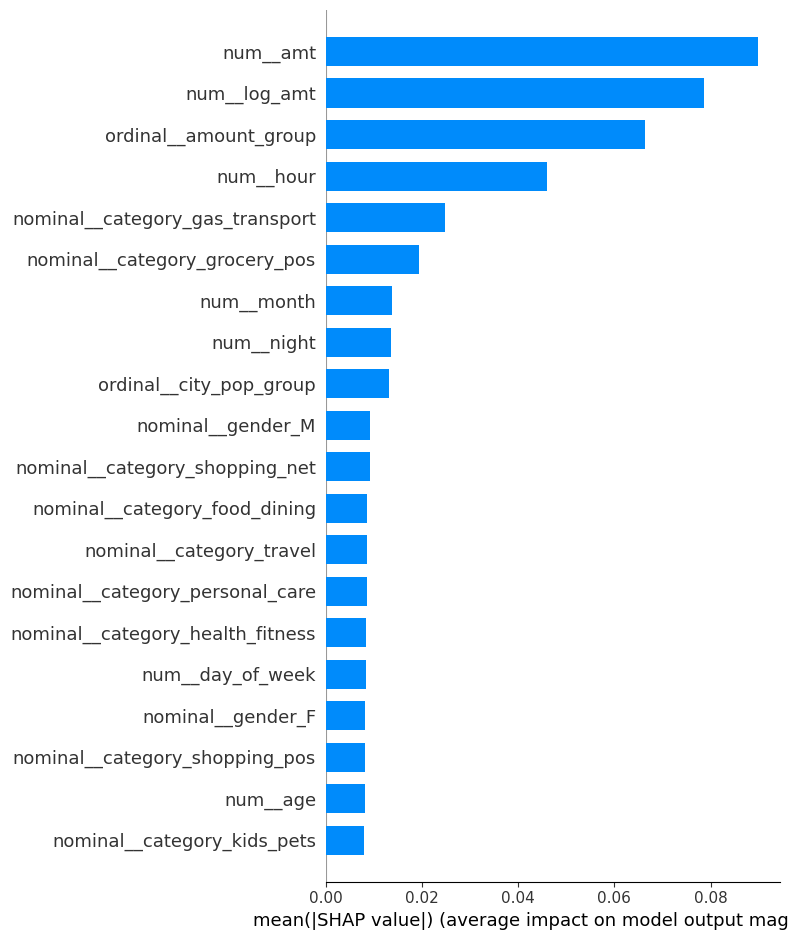

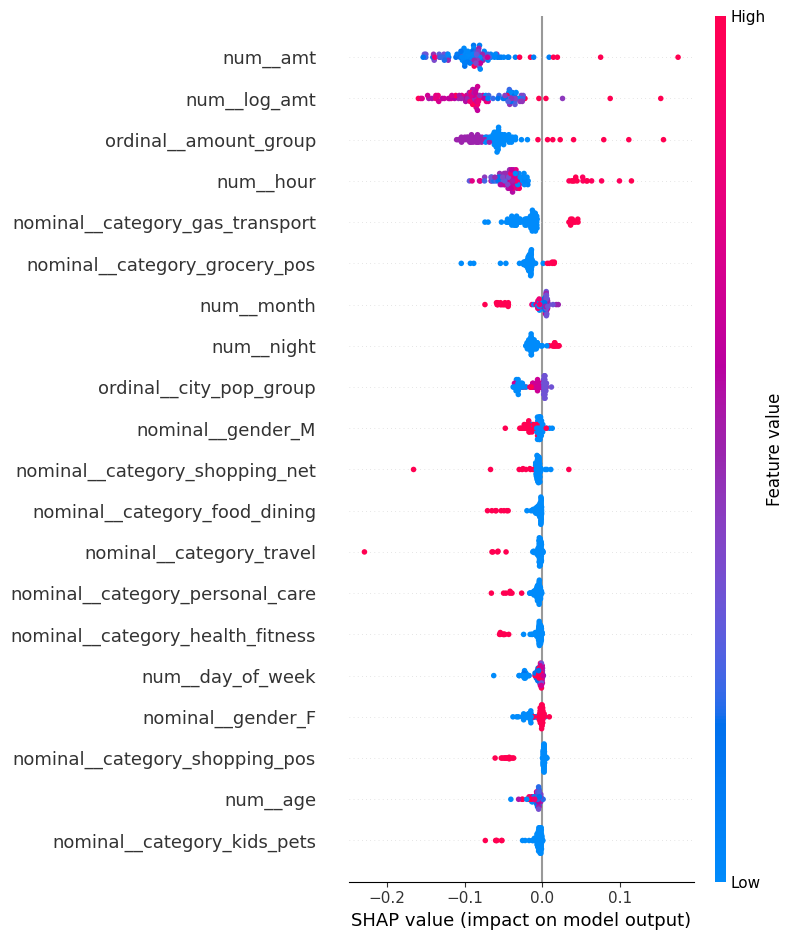

In [24]:
# Bar plot: global feature importance
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# Beeswarm plot: feature impact direction
shap.summary_plot(shap_values, X_sample)

# Explain one transaction


shap.initjs()

index = 0

shap.force_plot(
    explainer.expected_value[1],
    shap_values[index],
    X_sample.iloc[index]
)

The SHAP bar plot shows the overall importance of features based on their average impact on the model prediction. It shows which features influence the fraud prediction the most. In this model, num__amt is the most important feature, meaning transaction amount has the strongest overall effect on predicting fraud.

The SHAP beeswarm plot also shows feature importance, but in more detail. It explains how high and low values of each feature affect the model prediction. Dots on the right side push the prediction toward fraud, while dots on the left side push the prediction toward non-fraud. The color of the dots shows the feature value, where red means high value and blue means low value.